# Example Matrix-Free Operator Surface

Canonical matrix-free/operator notebook for the Krylov and operator-plan tranche.

## Scope

This notebook is the canonical example surface for `example_matrix_free_operator_surface`. It runs against the repo source tree through `/src`, shows direct public API usage, summarizes validation and benchmark status, and includes visual summaries.

In [1]:
import io
import json
import os
import re
import subprocess
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'arbplusjax').exists():
            return p
    raise RuntimeError(f'Could not locate repo root from: {start}')

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))
os.chdir(REPO_ROOT)

PYTHON = os.getenv('ARBPLUSJAX_PYTHON', sys.executable)
JAX_MODE = os.getenv('JAX_MODE', 'cpu').strip().lower()
JAX_DTYPE = os.getenv('JAX_DTYPE', 'float64').strip().lower()
RUN_ENV = os.environ.copy()
RUN_ENV['PYTHONPATH'] = str(REPO_ROOT / 'src') + os.pathsep + RUN_ENV.get('PYTHONPATH', '')
if JAX_MODE == 'cpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cpu'
elif JAX_MODE == 'gpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cuda'
RUN_ENV['JAX_ENABLE_X64'] = '1' if JAX_DTYPE == 'float64' else '0'
EXAMPLE_INPUT_ROOT = REPO_ROOT / 'examples' / 'inputs' / 'example_matrix_free_operator_surface'
EXAMPLE_OUTPUT_ROOT = REPO_ROOT / 'examples' / 'outputs' / 'example_matrix_free_operator_surface'
EXAMPLE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

def run(cmd: list[str], *, capture: bool = False):
    print('[cmd]', ' '.join(cmd))
    return subprocess.run(cmd, cwd=REPO_ROOT, env=RUN_ENV, text=True, capture_output=capture, check=True)


## Environment

The notebook reports interpreter, selected JAX mode, and the active backend/device view. Canonical retained execution in this repo state is CPU-oriented, but the notebook calling pattern remains CPU/GPU portable and explicitly parameterized for `float32` and `float64`.

In [2]:
SUPPORTED_JAX_MODES = ('cpu', 'gpu')
SUPPORTED_JAX_DTYPES = ('float32', 'float64')
if JAX_MODE not in SUPPORTED_JAX_MODES:
    raise ValueError(f'Unsupported JAX_MODE: {JAX_MODE}')
if JAX_DTYPE not in SUPPORTED_JAX_DTYPES:
    raise ValueError(f'Unsupported JAX_DTYPE: {JAX_DTYPE}')
print('python:', PYTHON)
print('jax_mode:', JAX_MODE)
print('jax_dtype:', JAX_DTYPE)
print('supported_jax_modes:', SUPPORTED_JAX_MODES)
print('supported_jax_dtypes:', SUPPORTED_JAX_DTYPES)
print('validation_slice:', 'cpu_current__gpu_portable_contract')
runtime = run([PYTHON, 'tools/check_jax_runtime.py'], capture=True)
print(runtime.stdout)
runtime_payload = json.loads(runtime.stdout)
(EXAMPLE_OUTPUT_ROOT / f'runtime_{JAX_MODE}.json').write_text(json.dumps(runtime_payload, indent=2) + '\n', encoding='utf-8')

python: /home/phili/miniforge3/envs/jax/bin/python
jax_mode: cpu
jax_dtype: float64
supported_jax_modes: ('cpu', 'gpu')
supported_jax_dtypes: ('float32', 'float64')
validation_slice: cpu_current__gpu_portable_contract
[cmd] /home/phili/miniforge3/envs/jax/bin/python tools/check_jax_runtime.py


{
  "platform": "cpu",
  "devices": [
    "TFRT_CPU_0"
  ],
  "jax_enable_x64": true,
  "env": {
    "JAX_PLATFORM_NAME": "",
    "XLA_PYTHON_CLIENT_PREALLOCATE": "",
    "XLA_PYTHON_CLIENT_MEM_FRACTION": "",
    "XLA_FLAGS": ""
  }
}



235

## Direct Usage

Build a small dense operator plan and exercise matrix-free apply, solve, and logdet-facing paths.

In [3]:
import jax.numpy as jnp
from arbplusjax import double_interval as di, jrb_mat

diag = jnp.array([2.0, 3.0, 5.0, 7.0], dtype=jnp.float64)
a_mid = jnp.diag(diag)
a = di.interval(a_mid, a_mid)
x = di.interval(jnp.array([1.0, 0.5, -0.25, 0.75], dtype=jnp.float64), jnp.array([1.0, 0.5, -0.25, 0.75], dtype=jnp.float64))
plan = jrb_mat.jrb_mat_dense_operator_plan_prepare(a)
sparse_plan = jrb_mat.jrb_mat_sparse_operator_plan_prepare(jrb_mat.sparse_common.dense_to_sparse_bcoo(a_mid, algebra='jrb'))
probes = jnp.stack([x, x], axis=0)
operator_results = {
    'apply': jrb_mat.jrb_mat_operator_plan_apply(plan, x),
    'sparse_apply': jrb_mat.jrb_mat_operator_plan_apply(sparse_plan, x),
    'solve': jrb_mat.jrb_mat_solve_action_point_jit(plan, x, symmetric=True),
    'logdet': jrb_mat.jrb_mat_logdet_slq_point(plan, probes, steps=4),
}
display(operator_results)

{'apply': Array([[ 2.  ,  2.  ],
        [ 1.5 ,  1.5 ],
        [-1.25, -1.25],
        [ 5.25,  5.25]], dtype=float64),
 'sparse_apply': Array([[ 2.  ,  2.  ],
        [ 1.5 ,  1.5 ],
        [-1.25, -1.25],
        [ 5.25,  5.25]], dtype=float64),
 'solve': Array([[ 0.5       ,  0.5       ],
        [ 0.16666667,  0.16666667],
        [-0.05      , -0.05      ],
        [ 0.10714286,  0.10714286]], dtype=float64),
 'logdet': Array(2.16296458, dtype=float64)}

## Production Pattern

Matrix-free production use should prepare operator plans once, reuse preconditioners, and keep problem size and Krylov steps stable across service requests where possible. This reduces recompiles and keeps diagnostics interpretable.

In [4]:
precond = jrb_mat.jrb_mat_jacobi_preconditioner_plan_prepare(plan)
solve_once = lambda rhs: jrb_mat.jrb_mat_solve_action_point_jit(plan, rhs, symmetric=True)
multi_shift_once = lambda rhs: jrb_mat.jrb_mat_multi_shift_solve_point_jit(plan, rhs, jnp.asarray([0.0, 0.5], dtype=jnp.float64), symmetric=True, preconditioner=precond)
matrix_free_service = {
    'operator_plan': jrb_mat.jrb_mat_operator_plan_apply(plan, x),
    'sparse_operator_plan': jrb_mat.jrb_mat_operator_plan_apply(sparse_plan, x),
    'solve_once': solve_once(x),
    'multi_shift_once': multi_shift_once(x),
}
display(matrix_free_service)

{'operator_plan': Array([[ 2.  ,  2.  ],
        [ 1.5 ,  1.5 ],
        [-1.25, -1.25],
        [ 5.25,  5.25]], dtype=float64),
 'sparse_operator_plan': Array([[ 2.  ,  2.  ],
        [ 1.5 ,  1.5 ],
        [-1.25, -1.25],
        [ 5.25,  5.25]], dtype=float64),
 'solve_once': Array([[ 0.5       ,  0.5       ],
        [ 0.16666667,  0.16666667],
        [-0.05      , -0.05      ],
        [ 0.10714286,  0.10714286]], dtype=float64),
 'multi_shift_once': Array([[[ 0.5       ,  0.5       ],
         [ 0.16666667,  0.16666667],
         [-0.05      , -0.05      ],
         [ 0.10714286,  0.10714286]],
 
        [[ 0.4       ,  0.4       ],
         [ 0.14285714,  0.14285714],
         [-0.04545455, -0.04545455],
         [ 0.1       ,  0.1       ]]], dtype=float64)}

## Extending Benchmarks

To benchmark another operator path, add a new metric block in `benchmark_matrix_free_krylov.py` with a stable metric name and then include that section in the notebook parsing.

## Fast JAX Point Pattern

Matrix-free fast JAX uses the family-owned compiled point kernels directly. The important contract is still the same: fixed problem shape, fixed Krylov steps, and no dynamic rescue logic in the hot path.

In [5]:
logdet_jit = jrb_mat.jrb_mat_logdet_slq_point_jit(plan, probes, 4)
logdet_ref = jrb_mat.jrb_mat_logdet_slq_point(plan, probes, 4)
display({'jit_value': logdet_jit, 'jit_matches_point': bool(jnp.allclose(logdet_jit, logdet_ref, rtol=1e-6, atol=1e-6))})

{'jit_value': Array(2.16296458, dtype=float64), 'jit_matches_point': True}

## AD Product Pattern

Matrix-free AD should be shown in both directions on operator-plan-first usage, since that is the production surface. This section differentiates a solve-based objective over both the RHS vector and a spectral shift parameter, then plots the paired sensitivities.

,rhs_entry,primal_rhs,grad_rhs,shift,primal_shift,grad_shift
0,-0.750000,0.509524,0.142857,0.000000,0.723810,-0.310862
1,-0.684783,0.518841,0.142857,0.021739,0.717119,-0.304710
2,-0.619565,0.528157,0.142857,0.043478,0.710560,-0.298744
3,-0.554348,0.537474,0.142857,0.065217,0.704129,-0.292957
4,-0.489130,0.546791,0.142857,0.086957,0.697821,-0.287342


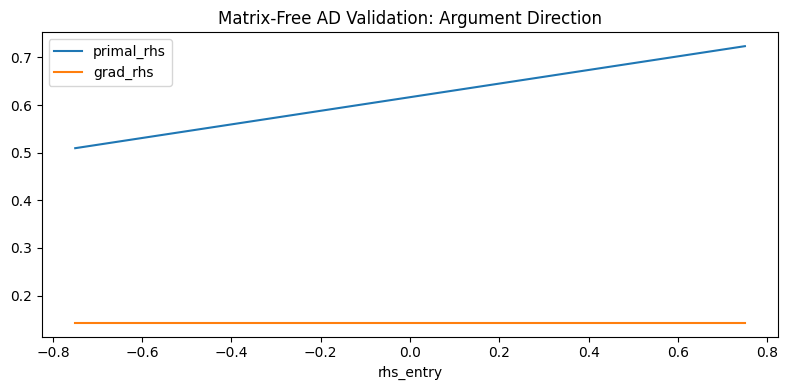

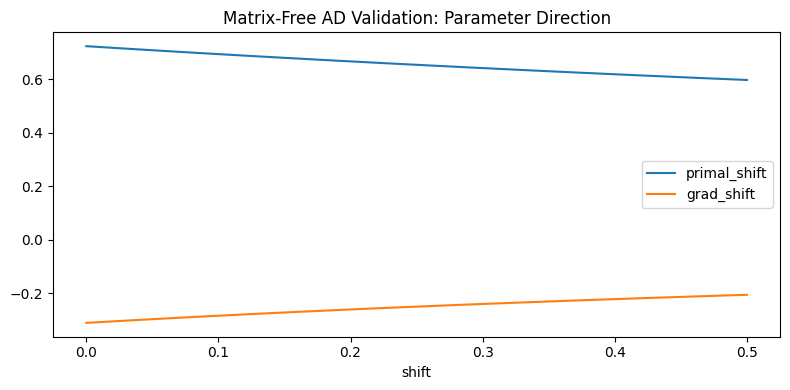

In [6]:
import jax
base_diag = jnp.array([2.0, 3.0, 5.0, 7.0], dtype=jnp.float64)
rhs_fixed = jnp.asarray([1.0, 0.5, -0.25, 0.75], dtype=jnp.float64)
base_plan = jrb_mat.jrb_mat_dense_operator_plan_prepare(di.interval(jnp.diag(base_diag), jnp.diag(base_diag)))
def mf_loss_rhs(v):
    solved = jrb_mat.jrb_mat_solve_action_point_jit(base_plan, di.interval(v, v), symmetric=True)
    return jnp.sum(di.midpoint(solved))
def mf_loss_shift(shift):
    solved = jrb_mat.jrb_mat_multi_shift_solve_point(base_plan, di.interval(rhs_fixed, rhs_fixed), jnp.asarray([shift], dtype=jnp.float64), symmetric=True)
    return jnp.sum(di.midpoint(solved))
rhs_sweep = jnp.linspace(-0.75, 0.75, 24, dtype=jnp.float64)
shift_sweep = jnp.linspace(0.0, 0.5, 24, dtype=jnp.float64)
primal_rhs = jax.vmap(lambda t: mf_loss_rhs(jnp.asarray([rhs_fixed[0], rhs_fixed[1], rhs_fixed[2], t], dtype=jnp.float64)))(rhs_sweep)
grad_rhs = jax.vmap(lambda t: jax.grad(mf_loss_rhs)(jnp.asarray([rhs_fixed[0], rhs_fixed[1], rhs_fixed[2], t], dtype=jnp.float64))[-1])(rhs_sweep)
primal_shift = jax.vmap(mf_loss_shift)(shift_sweep)
grad_shift = jax.vmap(jax.grad(mf_loss_shift))(shift_sweep)
ad_df = pd.DataFrame({'rhs_entry': np.asarray(rhs_sweep), 'primal_rhs': np.asarray(primal_rhs), 'grad_rhs': np.asarray(grad_rhs), 'shift': np.asarray(shift_sweep), 'primal_shift': np.asarray(primal_shift), 'grad_shift': np.asarray(grad_shift)})
display(ad_df.head())
ax = ad_df.plot(x='rhs_entry', y=['primal_rhs', 'grad_rhs'], figsize=(8, 4), title='Matrix-Free AD Validation: Argument Direction')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'ad_validation_argument_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()
ax = ad_df.plot(x='shift', y=['primal_shift', 'grad_shift'], figsize=(8, 4), title='Matrix-Free AD Validation: Parameter Direction')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'ad_validation_parameter_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()

## Validation Summary

Run the matrix-free contract, chassis, and AD-facing tests.

In [7]:
test_cmd = [
    PYTHON, '-m', 'pytest', '-q',
    'tests/test_matrix_free_basic.py',
    'tests/test_matfree_adjoints.py',
]
try:
    tests = run(test_cmd, capture=True)
    test_status = 'passed'
except subprocess.CalledProcessError as exc:
    tests = exc
    test_status = 'failed'
print(tests.stdout)
if tests.stderr:
    print(tests.stderr)
(EXAMPLE_OUTPUT_ROOT / f'pytest_{JAX_MODE}.txt').write_text((tests.stdout or '') + ('\n' + tests.stderr if tests.stderr else ''), encoding='utf-8')
display({'validation_status': test_status})

[cmd] /home/phili/miniforge3/envs/jax/bin/python -m pytest -q tests/test_matrix_free_basic.py tests/test_matfree_adjoints.py


.F.......F...................                                            [100%]
=================================== FAILURES ===================================
___________________ test_complex_matrix_free_basic_contracts ___________________

>   apply_point = jrb_mat.jrb_mat_operator_apply_point(plan, x)

tests/test_matrix_free_basic.py:54: 
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
src/arbplusjax/jrb_mat.py:1650: in jrb_mat_operator_apply_point
    return matrix_free_core.operator_apply_point(
src/arbplusjax/matrix_free_core.py:1949: in operator_apply_point
    out = point_from_midpoint(y)
src/arbplusjax/jrb_mat.py:141: in _jrb_point_interval
    return di.interval(di._below(x), di._above(x))
src/arbplusjax/double_interval.py:76: in _below
    return jnp.where(x <= huge, finite_branch, overflow_branch)
../../miniforge3/envs/jax/lib/python3.12/site-packages/jax/_src/numpy/lax_numpy.py:2785: in where
    return util._where(condition, x, y)
_ _ _ _

{'validation_status': 'failed'}

## Benchmark Summary

Run the matrix-free Krylov benchmark on a reduced section set and structure the emitted metrics.

In [8]:
completed = run([
    PYTHON, 'benchmarks/benchmark_matrix_free_krylov.py',
    '--n-real', '6', '--n-complex', '4', '--steps-real', '3', '--steps-complex', '3', '--warmup', '0', '--runs', '1',
    '--sections', 'real',
], capture=True)
print(completed.stdout)
rows = []
for line in completed.stdout.splitlines():
    if ': ' not in line:
        continue
    key, value = line.split(': ', 1)
    if key in {'warmup', 'runs', 'plan_precompile', 'sections'} or key.startswith('[matrix_free_krylov]'):
        continue
    try:
        rows.append({'metric': key, 'seconds': float(value)})
    except ValueError:
        pass
bench_df = pd.DataFrame(rows).sort_values('seconds')
bench_df.to_csv(EXAMPLE_OUTPUT_ROOT / f'matrix_free_benchmark_summary_{JAX_MODE}.csv', index=False)
display(bench_df.head(20))

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_matrix_free_krylov.py --n-real 6 --n-complex 4 --steps-real 3 --steps-complex 3 --warmup 0 --runs 1 --sections real


[matrix_free_krylov] running real
warmup: 0
runs: 1
plan_precompile: True
sections: real
real_apply_cold_s: 0.117673
real_apply_plan_cold_s: 0.126421
real_action_cold_s: 0.697791
real_action_plan_cold_s: 0.264641
real_restarted_action_cold_s: 0.203320
real_restarted_action_plan_cold_s: 0.199945
real_grad_cold_s: 0.259823
real_logdet_cold_s: 0.264770
real_logdet_plan_cold_s: 0.220622
real_det_cold_s: 0.243445
real_det_plan_cold_s: 0.257972
real_solve_action_cold_s: 0.163994
real_solve_action_plan_cold_s: 0.173416
real_inverse_action_cold_s: 0.160547
real_inverse_action_plan_cold_s: 0.162449
real_eigsh_cold_s: 0.195042
real_eigsh_plan_cold_s: 0.169201
real_minres_plan_cold_s: 0.305322
real_logdet_grad_cold_s: 0.320340
real_solve_action_plan_compile_s: 0.000295
real_solve_action_plan_execute_s: 0.000034
real_inverse_action_plan_compile_s: 0.000029
real_inverse_action_plan_execute_s: 0.000011
real_multi_shift_plan_compile_s: 0.202060
real_multi_shift_plan_execute_s: 0.000247
real_eigsh_res

,metric,seconds
22,real_inverse_action_plan_execute_s,0.000011
21,real_inverse_action_plan_compile_s,0.000029
20,real_solve_action_plan_execute_s,0.000034
36,real_apply_plan_warm_s,0.000044
38,real_action_plan_warm_s,0.000058
32,real_inverse_grad_plan_execute_s,0.000075
44,real_apply_plan_precompile_s,0.000084
45,real_action_plan_precompile_s,0.000094
42,real_inverse_action_plan_warm_s,0.000098
30,real_solve_grad_plan_execute_s,0.000102


## Comparison / Contrast

Compare dense-operator, sparse-operator, and solve/logdet-facing matrix-free usage so callers can decide when to stay dense, when to adapt sparse structure, and when to move fully into operator-free execution.

In [9]:
compare_df = bench_df[bench_df['metric'].str.contains('solve|matvec|logdet', regex=True, na=False)].copy()
display(compare_df.head(20))

,metric,seconds
20,real_solve_action_plan_execute_s,0.000034
30,real_solve_grad_plan_execute_s,0.000102
41,real_solve_action_plan_warm_s,0.000168
33,real_logdet_grad_compile_s,0.000248
46,real_logdet_plan_precompile_s,0.000271
34,real_logdet_grad_execute_s,0.000271
40,real_logdet_plan_warm_s,0.000279
19,real_solve_action_plan_compile_s,0.000295
39,real_logdet_warm_s,0.000347
11,real_solve_action_cold_s,0.163994


## Diagnostics

Matrix-free diagnostics are part of the production surface, so keep a compact summary of compile and execution metrics.

In [10]:
diag_rows = bench_df[bench_df['metric'].str.contains('compile|execute|cold|warm', regex=True, na=False)].head(20)
diag_rows.to_csv(EXAMPLE_OUTPUT_ROOT / f'matrix_free_diagnostics_{JAX_MODE}.csv', index=False)
display(diag_rows)

,metric,seconds
22,real_inverse_action_plan_execute_s,0.000011
21,real_inverse_action_plan_compile_s,0.000029
20,real_solve_action_plan_execute_s,0.000034
36,real_apply_plan_warm_s,0.000044
38,real_action_plan_warm_s,0.000058
32,real_inverse_grad_plan_execute_s,0.000075
44,real_apply_plan_precompile_s,0.000084
45,real_action_plan_precompile_s,0.000094
42,real_inverse_action_plan_warm_s,0.000098
30,real_solve_grad_plan_execute_s,0.000102


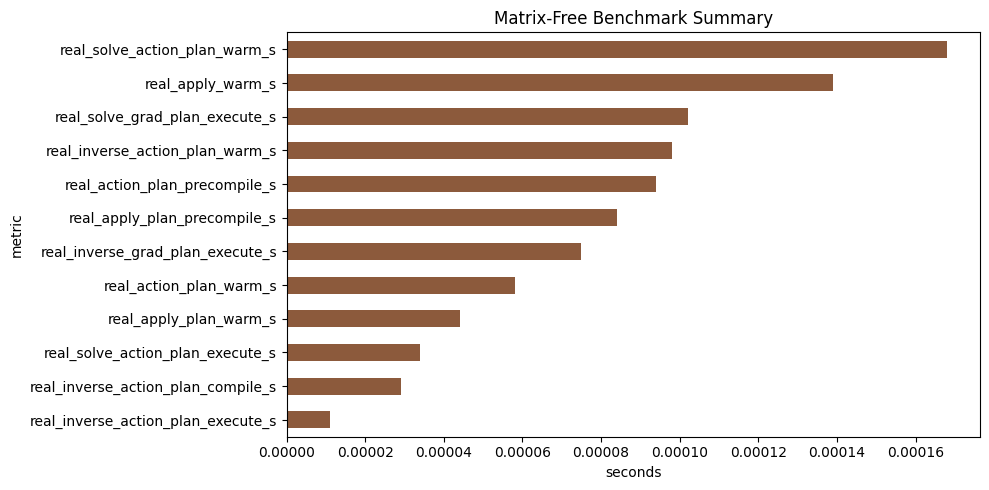

In [11]:
top = bench_df.head(12).copy()
ax = top.plot(x='metric', y='seconds', kind='barh', figsize=(10, 5), color='#8c5a3c', legend=False, title='Matrix-Free Benchmark Summary')
ax.set_xlabel('seconds')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'matrix_free_benchmark_summary_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()

In [12]:
summary_lines = [
    f'# Example Matrix-Free Operator Surface Summary ({JAX_MODE})',
    '',
    f'- backend: `{runtime_payload["platform"]}`',
    f'- benchmark_rows: `{len(bench_df)}`',
    f'- diagnostics_rows: `{len(diag_rows)}`',
    '',
    '## Fastest Metrics',
    '',
]
for row in top.to_dict(orient='records'):
    summary_lines.append(f"- `{row['metric']}`: {row['seconds']:.6g}s")
(EXAMPLE_OUTPUT_ROOT / f'summary_{JAX_MODE}.md').write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')
display('\n'.join(summary_lines[:12]))

'# Example Matrix-Free Operator Surface Summary (cpu)\n\n- backend: `cpu`\n- benchmark_rows: `48`\n- diagnostics_rows: `20`\n\n## Fastest Metrics\n\n- `real_inverse_action_plan_execute_s`: 1.1e-05s\n- `real_inverse_action_plan_compile_s`: 2.9e-05s\n- `real_solve_action_plan_execute_s`: 3.4e-05s\n- `real_apply_plan_warm_s`: 4.4e-05s'